# **Praktikum Mandiri 12 - Principal Component Analysis (PCA)**

# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Dataset

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Praktikum12/Data/cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Informasi Dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


# Cek Missing Value

In [5]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


# Cek Data Duplikat

In [6]:
df.duplicated().sum()

np.int64(0)

# Distribusi Kelas Target

In [7]:
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


# Encoding Label Target

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

df['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


# Pisahkan Fitur dan Label

In [17]:
X = df.drop(['diagnosis', 'Unnamed: 32'], axis=1)
y = df['diagnosis']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (569, 31)
Shape y: (569,)


# Train-Test Split (80:20)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (455, 31)
X_test: (114, 31)


# Standardisasi Data

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[-2.43221088e-01,  5.18558727e-01,  8.91825791e-01,
         4.24631702e-01,  3.83925436e-01, -9.74743706e-01,
        -6.89771505e-01, -6.88586446e-01, -3.98175254e-01,
        -1.03915470e+00, -8.25056321e-01, -1.09317755e-01,
        -5.59755400e-02, -2.10096206e-01, -1.59132582e-02,
        -1.00518399e+00, -9.11941990e-01, -6.62815884e-01,
        -6.52561081e-01, -7.01889114e-01, -2.75393571e-01,
         5.79797697e-01,  1.31324246e+00,  4.66908134e-01,
         4.45982711e-01, -5.96154777e-01, -6.34722227e-01,
        -6.10227299e-01, -2.35743918e-01,  5.45663235e-02,
         2.18367276e-02],
       [ 4.08373367e-01, -5.16364088e-01, -1.63971029e+00,
        -5.41348716e-01, -5.42961327e-01,  4.76219058e-01,
        -6.31833818e-01, -6.04281166e-01, -3.03074908e-01,
         5.21543093e-01, -4.54522896e-01, -6.04377961e-01,
        -1.00104604e+00, -5.85429002e-01, -4.93453793e-01,
         4.03212009e-01, -7.68173276e-01, -4.79187222e-01,
         1.14508478e-01, -1.42

# BASELINE MODEL: SVM TANPA PCA

In [20]:
svm_no_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_no_pca.fit(X_train_scaled, y_train)

y_pred_no_pca = svm_no_pca.predict(X_test_scaled)

acc_no_pca = accuracy_score(y_test, y_pred_no_pca)
print("Akurasi SVM tanpa PCA:", acc_no_pca)

print("\nClassification Report (tanpa PCA):")
print(classification_report(y_test, y_pred_no_pca))

Akurasi SVM tanpa PCA: 0.9649122807017544

Classification Report (tanpa PCA):
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# PCA (REDUKSI DIMENSI)

In [21]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.43184634 0.17962517]


# Visualisasi PCA 2D

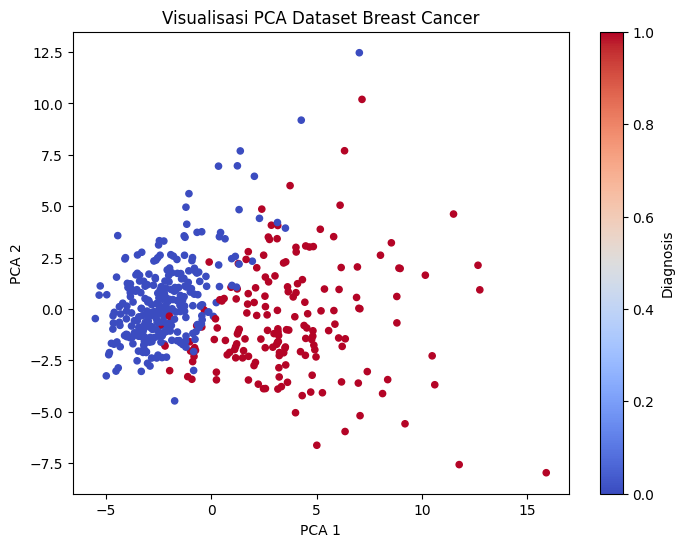

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='coolwarm', s=20)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Visualisasi PCA Dataset Breast Cancer")
plt.colorbar(label='Diagnosis')
plt.show()

# Visualisasi PCA 3D

In [26]:
# Apply PCA for 3 components for 3D visualization
pca_3d = PCA(n_components=3)
X_train_pca_3d = pca_3d.fit_transform(X_train_scaled)
X_test_pca_3d = pca_3d.transform(X_test_scaled)

print("Explained Variance Ratio (3 components):")
print(pca_3d.explained_variance_ratio_)
print("Cumulative Explained Variance (3 components):")
print(np.sum(pca_3d.explained_variance_ratio_))

Explained Variance Ratio (3 components):
[0.43184634 0.17962517 0.0935514 ]
Cumulative Explained Variance (3 components):
0.7050229101608617


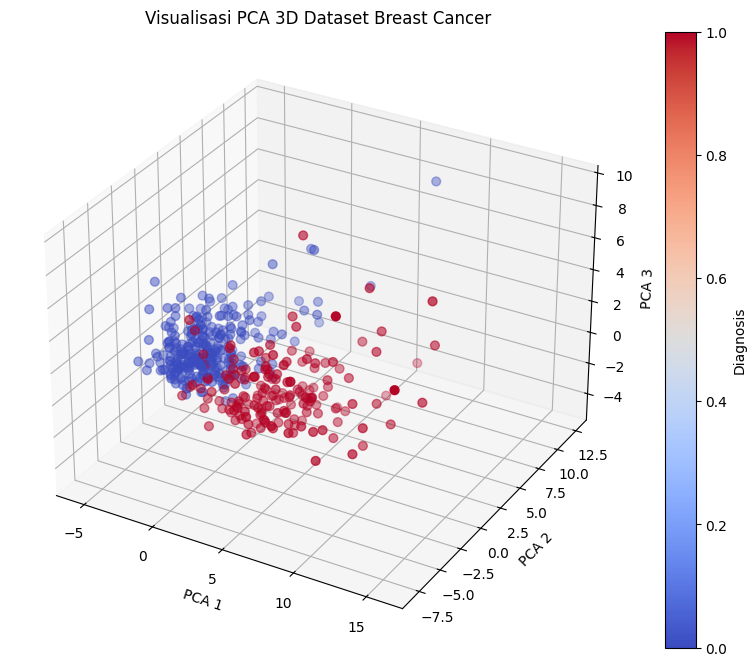

In [27]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_train_pca_3d[:, 0],
    X_train_pca_3d[:, 1],
    X_train_pca_3d[:, 2],
    c=y_train,
    cmap='coolwarm',
    s=40
)

ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
ax.set_title('Visualisasi PCA 3D Dataset Breast Cancer')
plt.colorbar(scatter, label='Diagnosis')
plt.show()

# Visualisasi Perbandingan SVM tanpa PCA & dengan PCA

/tmp/ipython-input-1730674238.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='coolwarm')


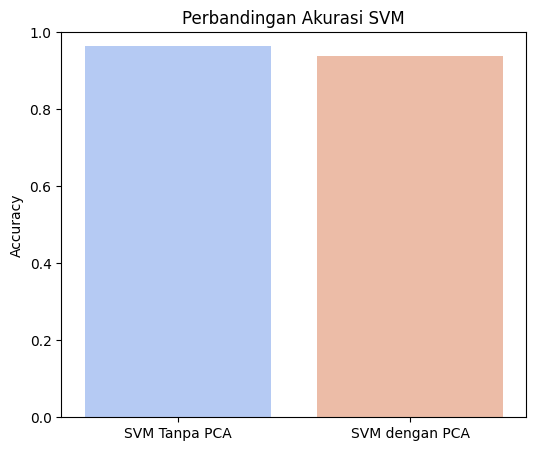

In [30]:
import seaborn as sns

models = ['SVM Tanpa PCA', 'SVM dengan PCA']
accuracies = [acc_no_pca, acc_pca]

plt.figure(figsize=(6,5))
sns.barplot(x=models, y=accuracies, palette='coolwarm')
plt.ylim(0, 1)
plt.title('Perbandingan Akurasi SVM')
plt.ylabel('Accuracy')
plt.show()